# XRAY CNN ESPEJO B
Opción B: cada bloque cuántico se reemplaza por

Conv2d(3x3) + BatchNorm2d + ReLU

# 0) IMPORTS

In [1]:
import os
import time
import math
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    roc_curve, roc_auc_score, average_precision_score,
    precision_recall_curve, accuracy_score, f1_score,
    confusion_matrix, classification_report, precision_score
)

# 1) CONFIGURACIÓN GLOBAL

In [2]:
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float32)

print("Using device:", DEVICE)
print("Torch default dtype:", torch.get_default_dtype())

Using device: cuda:0
Torch default dtype: torch.float32


# 2) HIPERPARÁMETROS Y RUTA DEL DATASET

In [3]:
IMG_SIZE = 256
BATCH_SIZE = 16

NUM_WORKERS = 0

FRAC_TRAIN = 0.80
FRAC_VAL = 0.10

EPOCHS = 20
LR_CL = 1e-3
WEIGHT_DECAY = 1e-5
DROPOUT_P = 0.20

# RUTA DEL DATASET (WINDOWS)

In [4]:
DATA_ROOT = r"C:\Users\lapic\datasets\Curated_XRay_256x256"

if not os.path.isdir(DATA_ROOT):
    raise FileNotFoundError(
        f"No encontré la carpeta del dataset en:\n{DATA_ROOT}\n\n"
        "Verifica que la ruta exista y que contenga subcarpetas de clases, por ejemplo:\n"
        "  COVID-19/\n"
        "  Normal/\n"
        "  Pneumonia-Bacterial/\n"
        "  Pneumonia-Viral/"
    )

print(f"[Config] DATA_ROOT = {DATA_ROOT}")
print(f"[Config] IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | LR_CL={LR_CL}")

[Config] DATA_ROOT = C:\Users\lapic\datasets\Curated_XRay_256x256
[Config] IMG_SIZE=256 | BATCH=16 | LR_CL=0.001


# 3) TRANSFORMACIONES

In [5]:
tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# 4) DATASET Y FILTRO COVID/NORMAL

In [6]:
full_ds = ImageFolder(DATA_ROOT, transform=tf)
print("[Info] Clases detectadas:", full_ds.classes)
print("[Info] class_to_idx:", full_ds.class_to_idx)

def _find_class_idx(classes, keyword):
    kw = keyword.lower()
    for i, c in enumerate(classes):
        if kw in c.lower():
            return i
    return None

pos_old = _find_class_idx(full_ds.classes, "covid")
neg_old = _find_class_idx(full_ds.classes, "normal")

if pos_old is None or neg_old is None:
    raise ValueError(
        f"No detecté 'covid' y/o 'normal'. Clases encontradas: {full_ds.classes}"
    )

POS_NAME = full_ds.classes[pos_old]
NEG_NAME = full_ds.classes[neg_old]

print(f"[Info] Clase positiva = {POS_NAME} (old idx={pos_old})")
print(f"[Info] Clase negativa = {NEG_NAME} (old idx={neg_old})")

abs_indices = []
bin_targets = []

for abs_i, (_, old_y) in enumerate(full_ds.samples):
    if old_y == neg_old:
        abs_indices.append(abs_i)
        bin_targets.append(0.0)
    elif old_y == pos_old:
        abs_indices.append(abs_i)
        bin_targets.append(1.0)

abs_indices = np.asarray(abs_indices, dtype=np.int64)
bin_targets = np.asarray(bin_targets, dtype=np.float32)

print(f"[Info] Total binarias (COVID/Normal): {len(abs_indices)}")
print(f"[Info] #Normal = {(bin_targets == 0).sum()} | #COVID = {(bin_targets == 1).sum()}")

[Info] Clases detectadas: ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
[Info] class_to_idx: {'COVID-19': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}
[Info] Clase positiva = COVID-19 (old idx=0)
[Info] Clase negativa = Normal (old idx=1)
[Info] Total binarias (COVID/Normal): 4552
[Info] #Normal = 3271 | #COVID = 1281


# 4.5) DATASET BINARIO REMAPEADO

    Dataset binario correcto:
    - toma la imagen del dataset base usando índices absolutos
    - ignora la etiqueta original de ImageFolder
    - devuelve la etiqueta binaria remapeada correcta

In [7]:
class BinarySubset(Dataset):

    def __init__(self, base_dataset, abs_indices, targets):
        self.base_dataset = base_dataset
        self.abs_indices = np.asarray(abs_indices, dtype=np.int64)
        self.targets = np.asarray(targets, dtype=np.float32)

        assert len(self.abs_indices) == len(self.targets), \
            "abs_indices y targets deben tener la misma longitud"

    def __len__(self):
        return len(self.abs_indices)

    def __getitem__(self, i):
        x, _ = self.base_dataset[self.abs_indices[i]]
        y = torch.tensor(self.targets[i], dtype=torch.float32)
        return x, y

# 5) SPLIT ESTRATIFICADO

In [8]:
rng = np.random.default_rng(SEED)

idx0 = np.where(bin_targets == 0)[0]
idx1 = np.where(bin_targets == 1)[0]

rng.shuffle(idx0)
rng.shuffle(idx1)

def split_class(idxs, frac_train=0.8, frac_val=0.1):
    n = len(idxs)
    n_tr = int(round(frac_train * n))
    n_va = int(round(frac_val * n))
    tr = idxs[:n_tr]
    va = idxs[n_tr:n_tr+n_va]
    te = idxs[n_tr+n_va:]
    return tr, va, te

tr0, va0, te0 = split_class(idx0, FRAC_TRAIN, FRAC_VAL)
tr1, va1, te1 = split_class(idx1, FRAC_TRAIN, FRAC_VAL)

tr_idx = np.concatenate([tr0, tr1]); rng.shuffle(tr_idx)
va_idx = np.concatenate([va0, va1]); rng.shuffle(va_idx)
te_idx = np.concatenate([te0, te1]); rng.shuffle(te_idx)

train_abs = abs_indices[tr_idx]
val_abs   = abs_indices[va_idx]
test_abs  = abs_indices[te_idx]

train_targets = bin_targets[tr_idx]
val_targets   = bin_targets[va_idx]
test_targets  = bin_targets[te_idx]

print(f"[Split] Train={len(train_abs)} | Val={len(val_abs)} | Test={len(test_abs)}")
print(f"[Split] Train Normal/COVID = {(train_targets==0).sum()}/{(train_targets==1).sum()}")
print(f"[Split] Val   Normal/COVID = {(val_targets==0).sum()}/{(val_targets==1).sum()}")
print(f"[Split] Test  Normal/COVID = {(test_targets==0).sum()}/{(test_targets==1).sum()}")

train_ds = BinarySubset(full_ds, train_abs, train_targets)
val_ds   = BinarySubset(full_ds, val_abs, val_targets)
test_ds  = BinarySubset(full_ds, test_abs, test_targets)

[Split] Train=3642 | Val=455 | Test=455
[Split] Train Normal/COVID = 2617/1025
[Split] Val   Normal/COVID = 327/128
[Split] Test  Normal/COVID = 327/128


# 6) DATALOADERS

In [9]:
g_cpu = torch.Generator(device="cpu")
g_cpu.manual_seed(SEED)

loader_kwargs_train = dict(
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_cpu,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

loader_kwargs_eval = dict(
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

if NUM_WORKERS > 0:
    loader_kwargs_train["persistent_workers"] = True
    loader_kwargs_eval["persistent_workers"] = True

train_loader = DataLoader(train_ds, **loader_kwargs_train)
val_loader   = DataLoader(val_ds, **loader_kwargs_eval)
test_loader  = DataLoader(test_ds, **loader_kwargs_eval)

xb, yb = next(iter(train_loader))
print("[Sanity] Batch x shape:", xb.shape, "| y shape:", yb.shape)

[Sanity] Batch x shape: torch.Size([16, 1, 256, 256]) | y shape: torch.Size([16])


# 7) BLOQUE CLÁSICO ESPEJO DEL BLOQUE CUÁNTICO
Opción B: Conv2d(3x3) + BN + ReLU

    Espejo clásico del bloque cuántico, opción B:
    - Conv2d 3x3 con stride=2
    - BatchNorm2d
    - ReLU

    Esto ya convierte cada etapa de extracción en un bloque CNN clásico
    más estándar que la opción A.

In [10]:
class ClassicalPatchConvBNReLU2x2Stride2(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=False)
        )
        self._dbg_printed = False

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        out = self.block(x)

        if not self._dbg_printed:
            print(
                f"[ClassicalPatchConvBNReLU] Cin={self.in_channels} -> Cout={self.out_channels} | "
                f"in={tuple(x.shape)} -> out={tuple(out.shape)}"
            )
            self._dbg_printed = True

        return out

# 8) MODELO CNN ESPEJO B
Reemplaza q1..q5 por conv+bn+relu y mantiene pw1..pw5

        # Espejo de la arquitectura híbrida:
        # q1(out=4)  -> pw1(4->16)
        # q2(out=16) -> pw2(16->32)
        # q3(out=32) -> pw3(32->32)
        # q4(out=32) -> pw4(32->32)
        # q5(out=32) -> pw5(32->32)

In [11]:
class ClassicalMirrorNet256_B(nn.Module):
    def __init__(self):
        super().__init__()

        self.c1  = ClassicalPatchConvBNReLU2x2Stride2(1, 4)
        self.pw1 = nn.Conv2d(4, 16, 1)

        self.c2  = ClassicalPatchConvBNReLU2x2Stride2(16, 16)
        self.pw2 = nn.Conv2d(16, 32, 1)

        self.c3  = ClassicalPatchConvBNReLU2x2Stride2(32, 32)
        self.pw3 = nn.Conv2d(32, 32, 1)

        self.c4  = ClassicalPatchConvBNReLU2x2Stride2(32, 32)
        self.pw4 = nn.Conv2d(32, 32, 1)

        self.c5  = ClassicalPatchConvBNReLU2x2Stride2(32, 32)
        self.pw5 = nn.Conv2d(32, 32, 1)

        self.dropout = nn.Dropout(DROPOUT_P)
        self.fc1 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.to(dtype=torch.float32)

        x = self.c1(x)
        x = self.pw1(x)
        x = F.relu(x, inplace=False)

        x = self.c2(x)
        x = self.pw2(x)
        x = F.relu(x, inplace=False)

        x = self.c3(x)
        x = self.pw3(x)
        x = F.relu(x, inplace=False)

        x = self.c4(x)
        x = self.pw4(x)
        x = F.relu(x, inplace=False)

        x = self.c5(x)
        x = self.pw5(x)
        x = F.relu(x, inplace=False)

        # x: (B, 32, 8, 8)
        x = x.mean(dim=(2, 3))  # Global Average Pool -> (B, 32)
        x = self.dropout(x)
        x = F.relu(self.fc1(x), inplace=False)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# 9) CONSTRUIR MODELO Y SANITY CHECK

In [12]:
model = ClassicalMirrorNet256_B().to(DEVICE)

with torch.no_grad():
    xdummy = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE, dtype=torch.float32)
    ydummy = model(xdummy)
    print("[Sanity] Output model:", ydummy.shape)

print(model)

[ClassicalPatchConvBNReLU] Cin=1 -> Cout=4 | in=(2, 1, 256, 256) -> out=(2, 4, 128, 128)
[ClassicalPatchConvBNReLU] Cin=16 -> Cout=16 | in=(2, 16, 128, 128) -> out=(2, 16, 64, 64)
[ClassicalPatchConvBNReLU] Cin=32 -> Cout=32 | in=(2, 32, 64, 64) -> out=(2, 32, 32, 32)
[ClassicalPatchConvBNReLU] Cin=32 -> Cout=32 | in=(2, 32, 32, 32) -> out=(2, 32, 16, 16)
[ClassicalPatchConvBNReLU] Cin=32 -> Cout=32 | in=(2, 32, 16, 16) -> out=(2, 32, 8, 8)
[Sanity] Output model: torch.Size([2, 1])
ClassicalMirrorNet256_B(
  (c1): ClassicalPatchConvBNReLU2x2Stride2(
    (block): Sequential(
      (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (pw1): Conv2d(4, 16, kernel_size=(1, 1), stride=(1, 1))
  (c2): ClassicalPatchConvBNReLU2x2Stride2(
    (block): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False

# 10) CONTEO DE PARÁMETROS

In [13]:
def count_parameters(model):
    total = 0
    quantum = 0
    classical = 0

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        n = p.numel()
        total += n
        # En esta versión no hay parámetros cuánticos
        if "weights" in name:
            quantum += n
        else:
            classical += n

    return total, quantum, classical

total_p, quantum_p, classical_p = count_parameters(model)
print(f"Parámetros totales   : {total_p:,}")
print(f"Parámetros cuánticos : {quantum_p:,}")
print(f"Parámetros clásicos  : {classical_p:,}")

Parámetros totales   : 36,189
Parámetros cuánticos : 0
Parámetros clásicos  : 36,189


# 11) LOSS, OPTIMIZER, SCHEDULER

In [14]:
n_pos_tr = int((train_targets == 1).sum())
n_neg_tr = int((train_targets == 0).sum())
pos_weight_val = n_neg_tr / max(1, n_pos_tr)
print(f"[Info] pos_weight usado = {pos_weight_val:.3f}")

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_val], device=DEVICE, dtype=torch.float32)
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_CL,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

[Info] pos_weight usado = 2.553


# 12) INICIALIZACIÓN DEL BIAS FINAL

In [15]:
p_pos = float((train_targets == 1).mean())
b0 = float(np.log(p_pos / max(1e-12, (1.0 - p_pos))))

with torch.no_grad():
    nn.init.normal_(model.fc2.weight, mean=0.0, std=0.01)
    model.fc2.bias.fill_(b0)

print(f"[Init] fc2.bias <- logit(p_pos) = {b0:.4f} (p_pos={p_pos:.4f})")

[Init] fc2.bias <- logit(p_pos) = -0.9373 (p_pos=0.2814)


# 13) HELPERS DE MÉTRICAS

In [16]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def confusion_terms(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]
    return cm, tn, fp, fn, tp

def balanced_acc_from_preds(y_true, y_pred):
    _, tn, fp, fn, tp = confusion_terms(y_true, y_pred)
    tnr = tn / max(1, tn + fp)
    tpr = tp / max(1, tp + fn)
    return 0.5 * (tnr + tpr)

def best_threshold_youden(y_true, probs):
    fpr, tpr, thrs = roc_curve(y_true, probs)
    j = tpr - fpr
    idx = int(np.argmax(j))
    thr = float(thrs[idx])
    if not np.isfinite(thr):
        thr = 0.5
    thr = min(max(thr, 0.0), 1.0)
    return thr

def metrics_at_threshold(y_true, probs, thr=0.5):
    y_pred = (probs >= thr).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bacc = balanced_acc_from_preds(y_true, y_pred)

    cm, tn, fp, fn, tp = confusion_terms(y_true, y_pred)
    sensitivity = tp / max(1, tp + fn)
    specificity = tn / max(1, tn + fp)
    pred_pos_rate = y_pred.mean()

    return {
        "thr": thr,
        "acc": acc,
        "f1": f1,
        "bacc": bacc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "pred_pos_rate": pred_pos_rate,
        "cm": cm
    }

def print_metrics_block(title, res):
    print(f"\n{title}")
    print(
        f"loss={res['loss']:.4f} | auc={res['auc']:.4f} | pr_auc={res['pr_auc']:.4f}\n"
        f"@0.5  acc={res['m05']['acc']:.4f} | f1={res['m05']['f1']:.4f} | bAcc={res['m05']['bacc']:.4f} | "
        f"sens={res['m05']['sensitivity']:.4f} | spec={res['m05']['specificity']:.4f} | pred1={res['m05']['pred_pos_rate']:.4f}\n"
        f"@thr* acc={res['mth']['acc']:.4f} | f1={res['mth']['f1']:.4f} | bAcc={res['mth']['bacc']:.4f} | "
        f"sens={res['mth']['sensitivity']:.4f} | spec={res['mth']['specificity']:.4f} | pred1={res['mth']['pred_pos_rate']:.4f} | thr={res['thr']:.4f}"
    )

# 14) TRAIN / VALIDATION POR ÉPOCA

In [17]:
def train_epoch(loader):
    model.train()
    total_loss, total, total_correct = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = (logits >= 0).long()
        total_correct += (preds == yb.long()).sum().item()
        total += xb.size(0)

    return total_loss / total, total_correct / total

@torch.no_grad()
def eval_epoch(loader, expected_targets=None, tag="val"):
    model.eval()
    all_logits, all_y = [], []
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / total
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)
    probs = sigmoid_np(logits)

    if expected_targets is not None:
        assert len(expected_targets) == len(y_true), \
            f"[{tag}] Esperaba {len(expected_targets)} targets, pero obtuve {len(y_true)}"
        assert np.all(expected_targets.astype(int) == y_true), \
            f"[{tag}] Los targets del loader no coinciden con expected_targets"

    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")

    try:
        pr_auc = average_precision_score(y_true, probs)
    except Exception:
        pr_auc = float("nan")

    m05 = metrics_at_threshold(y_true, probs, thr=0.5)
    thr = best_threshold_youden(y_true, probs)
    mth = metrics_at_threshold(y_true, probs, thr=thr)

    return {
        "loss": avg_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "thr": thr,
        "m05": m05,
        "mth": mth,
        "logits": logits,
        "probs": probs,
        "y_true": y_true
    }

# 15) HELPERS DE CHECKPOINTS

In [18]:
def clone_state_dict_cpu(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

best_models = {
    "val_loss":    {"best": float("inf"),   "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_bacc_th": {"best": -float("inf"),  "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_f1_th":   {"best": -float("inf"),  "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
    "val_auc":     {"best": -float("inf"),  "epoch": -1, "thr": 0.5, "state": None, "val_metrics": None},
}

def maybe_update_checkpoint(name, score, epoch, thr, val_res, mode="max"):
    current_best = best_models[name]["best"]
    improved = (score < current_best) if mode == "min" else (score > current_best)

    if improved:
        best_models[name]["best"] = float(score)
        best_models[name]["epoch"] = int(epoch)
        best_models[name]["thr"] = float(thr)
        best_models[name]["state"] = clone_state_dict_cpu(model)
        best_models[name]["val_metrics"] = copy.deepcopy(val_res)

def load_checkpoint_from_registry(name):
    pack = best_models[name]
    if pack["state"] is None:
        raise ValueError(f"No hay checkpoint guardado para {name}")
    model.load_state_dict(pack["state"])
    model.to(DEVICE)
    return pack["thr"], pack["epoch"]

# 16) LOOP PRINCIPAL + MÚLTIPLES CHECKPOINTS

In [19]:
history = {
    "tr_loss": [], "tr_acc05": [],
    "va_loss": [], "va_auc": [], "va_pr": [],
    "va_acc05": [], "va_f105": [], "va_bacc05": [], "va_pred105": [],
    "va_sens05": [], "va_spec05": [],
    "va_thr": [],
    "va_accth": [], "va_f1th": [], "va_baccth": [], "va_pred1th": [],
    "va_sensth": [], "va_specth": [],
    "lr_cl": []
}

for ep in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc05 = train_epoch(train_loader)
    val_res = eval_epoch(val_loader, expected_targets=val_targets, tag="val")

    va_loss = val_res["loss"]
    scheduler.step(va_loss)

    dt = time.time() - t0
    current_lr = optimizer.param_groups[0]["lr"]

    history["tr_loss"].append(tr_loss)
    history["tr_acc05"].append(tr_acc05)

    history["va_loss"].append(val_res["loss"])
    history["va_auc"].append(val_res["auc"])
    history["va_pr"].append(val_res["pr_auc"])

    history["va_acc05"].append(val_res["m05"]["acc"])
    history["va_f105"].append(val_res["m05"]["f1"])
    history["va_bacc05"].append(val_res["m05"]["bacc"])
    history["va_pred105"].append(val_res["m05"]["pred_pos_rate"])
    history["va_sens05"].append(val_res["m05"]["sensitivity"])
    history["va_spec05"].append(val_res["m05"]["specificity"])

    history["va_thr"].append(val_res["thr"])
    history["va_accth"].append(val_res["mth"]["acc"])
    history["va_f1th"].append(val_res["mth"]["f1"])
    history["va_baccth"].append(val_res["mth"]["bacc"])
    history["va_pred1th"].append(val_res["mth"]["pred_pos_rate"])
    history["va_sensth"].append(val_res["mth"]["sensitivity"])
    history["va_specth"].append(val_res["mth"]["specificity"])

    history["lr_cl"].append(current_lr)

    maybe_update_checkpoint("val_loss",    val_res["loss"],           ep, val_res["thr"], val_res, mode="min")
    maybe_update_checkpoint("val_bacc_th", val_res["mth"]["bacc"],   ep, val_res["thr"], val_res, mode="max")
    maybe_update_checkpoint("val_f1_th",   val_res["mth"]["f1"],     ep, val_res["thr"], val_res, mode="max")
    maybe_update_checkpoint("val_auc",     val_res["auc"],           ep, val_res["thr"], val_res, mode="max")

    print(
        f"Época {ep:02d} (dt={dt:.1f}s) | "
        f"Train loss={tr_loss:.4f} acc@0.5={100*tr_acc05:.1f}% | "
        f"Val loss={val_res['loss']:.4f} AUC={val_res['auc']:.3f} PR-AUC={val_res['pr_auc']:.3f} | "
        f"@0.5 acc={100*val_res['m05']['acc']:.1f}% F1={val_res['m05']['f1']:.3f} bAcc={val_res['m05']['bacc']:.3f} pred1={100*val_res['m05']['pred_pos_rate']:.1f}% | "
        f"@thr* acc={100*val_res['mth']['acc']:.1f}% F1={val_res['mth']['f1']:.3f} bAcc={val_res['mth']['bacc']:.3f} pred1={100*val_res['mth']['pred_pos_rate']:.1f}% thr={val_res['thr']:.3f} | "
        f"LR={current_lr:.2e}"
    )

Época 01 (dt=21.9s) | Train loss=0.5447 acc@0.5=87.5% | Val loss=0.1759 AUC=0.997 PR-AUC=0.992 | @0.5 acc=97.4% F1=0.951 bAcc=0.956 pred1=25.9% | @thr* acc=97.8% F1=0.961 bAcc=0.975 pred1=28.6% thr=0.285 | LR=1.00e-03
Época 02 (dt=21.4s) | Train loss=0.2243 acc@0.5=94.9% | Val loss=0.1389 AUC=0.997 PR-AUC=0.992 | @0.5 acc=95.2% F1=0.920 bAcc=0.964 pred1=32.5% | @thr* acc=97.4% F1=0.955 bAcc=0.977 pred1=29.9% thr=0.794 | LR=1.00e-03
Época 03 (dt=21.2s) | Train loss=0.1946 acc@0.5=96.3% | Val loss=0.1838 AUC=0.998 PR-AUC=0.995 | @0.5 acc=94.5% F1=0.911 bAcc=0.962 pred1=33.6% | @thr* acc=98.0% F1=0.965 bAcc=0.979 pred1=28.8% thr=0.981 | LR=1.00e-03
Época 04 (dt=21.7s) | Train loss=0.1492 acc@0.5=97.4% | Val loss=0.0615 AUC=0.999 PR-AUC=0.997 | @0.5 acc=98.0% F1=0.966 bAcc=0.986 pred1=30.1% | @thr* acc=99.6% F1=0.992 bAcc=0.997 pred1=28.6% thr=0.908 | LR=1.00e-03
Época 05 (dt=21.4s) | Train loss=0.1590 acc@0.5=97.4% | Val loss=0.0447 AUC=0.999 PR-AUC=0.998 | @0.5 acc=98.7% F1=0.977 bAcc=0.

# 17) GRÁFICAS COMPLETAS

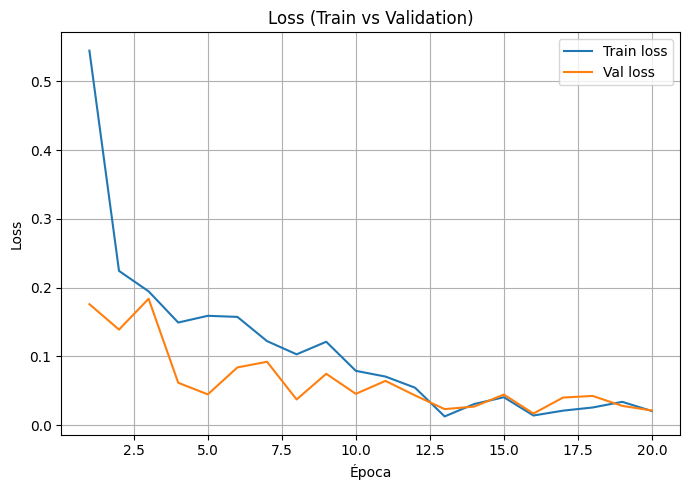

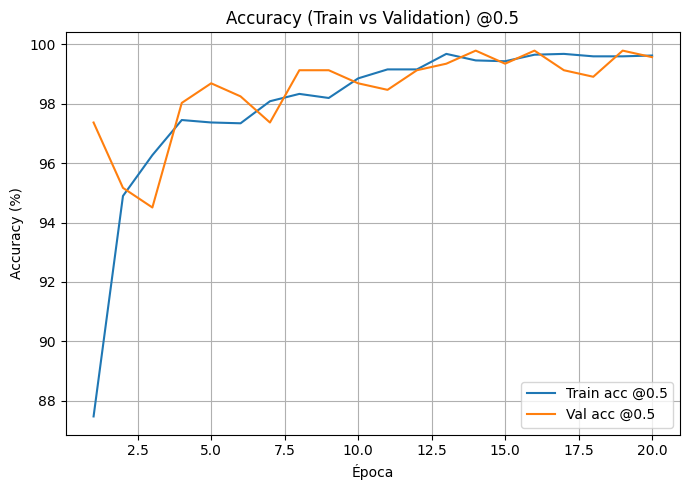

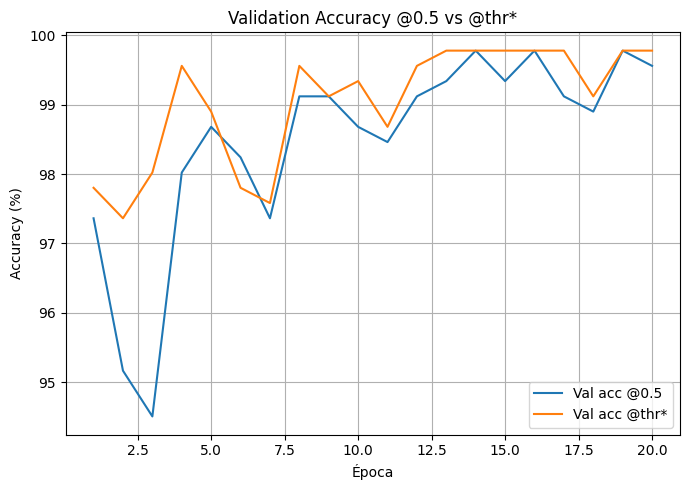

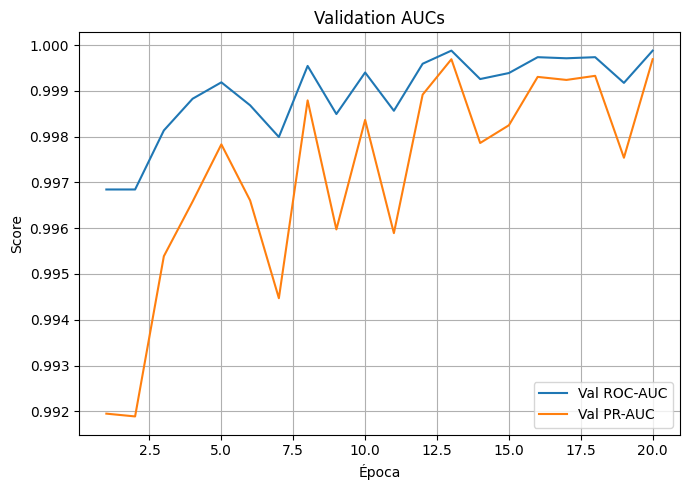

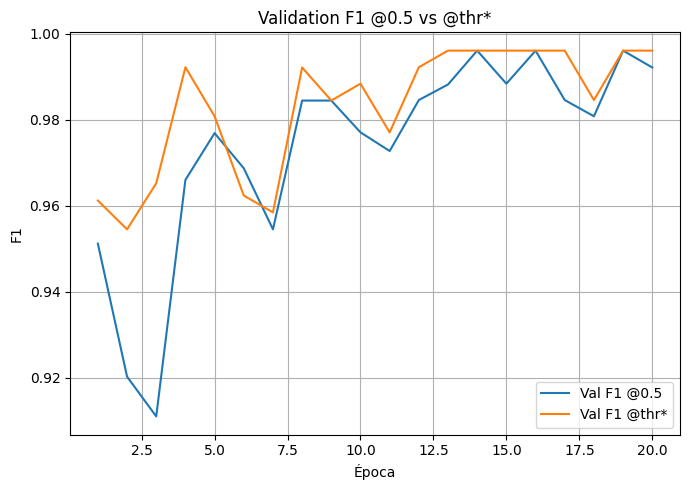

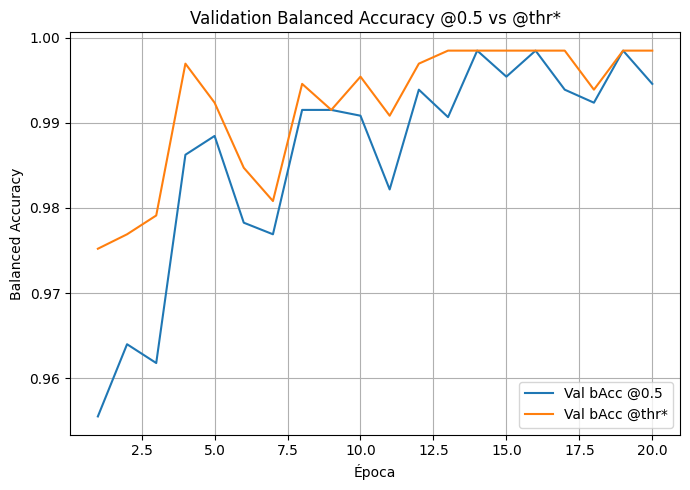

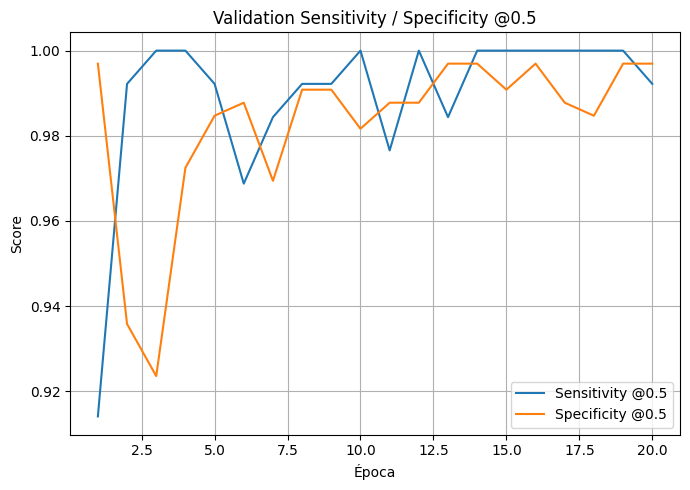

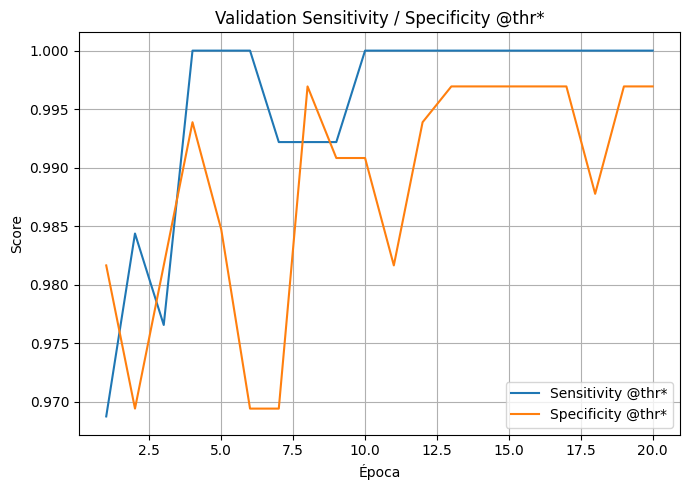

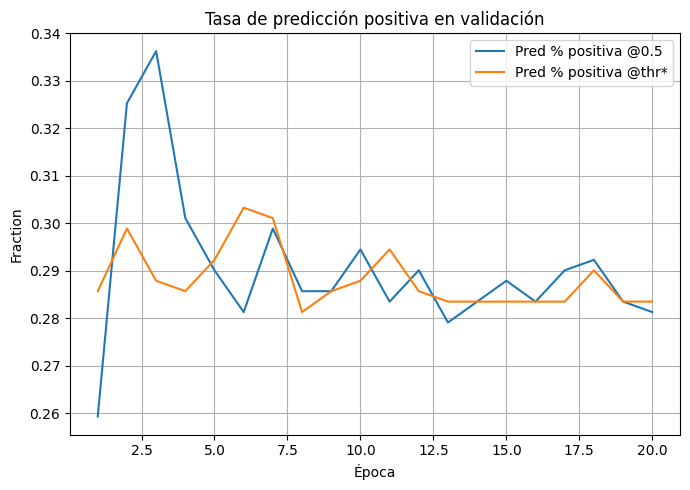

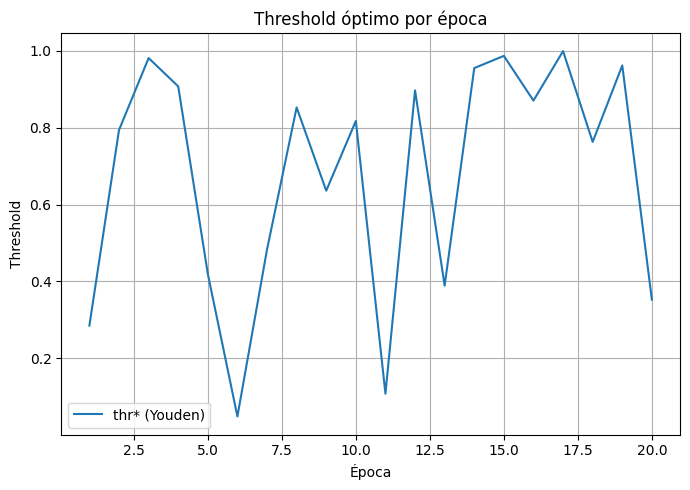

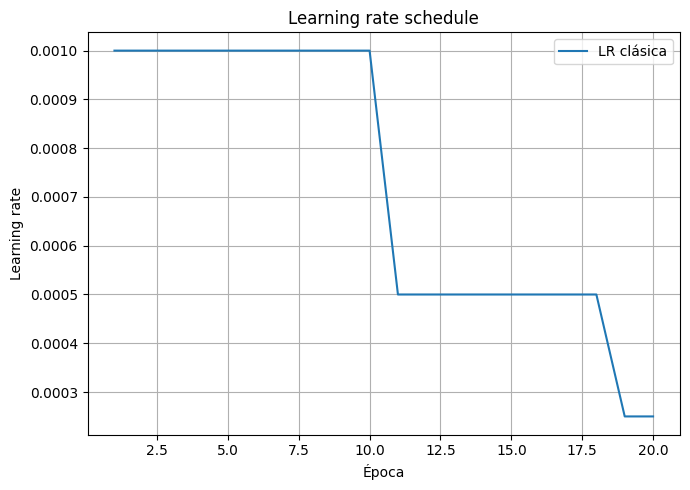

In [20]:
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["tr_loss"], label="Train loss")
plt.plot(epochs, history["va_loss"], label="Val loss")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.title("Loss (Train vs Validation)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, np.array(history["tr_acc05"]) * 100, label="Train acc @0.5")
plt.plot(epochs, np.array(history["va_acc05"]) * 100, label="Val acc @0.5")
plt.xlabel("Época"); plt.ylabel("Accuracy (%)")
plt.title("Accuracy (Train vs Validation) @0.5")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, np.array(history["va_acc05"]) * 100, label="Val acc @0.5")
plt.plot(epochs, np.array(history["va_accth"]) * 100, label="Val acc @thr*")
plt.xlabel("Época"); plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_auc"], label="Val ROC-AUC")
plt.plot(epochs, history["va_pr"], label="Val PR-AUC")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation AUCs")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_f105"], label="Val F1 @0.5")
plt.plot(epochs, history["va_f1th"], label="Val F1 @thr*")
plt.xlabel("Época"); plt.ylabel("F1")
plt.title("Validation F1 @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_bacc05"], label="Val bAcc @0.5")
plt.plot(epochs, history["va_baccth"], label="Val bAcc @thr*")
plt.xlabel("Época"); plt.ylabel("Balanced Accuracy")
plt.title("Validation Balanced Accuracy @0.5 vs @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_sens05"], label="Sensitivity @0.5")
plt.plot(epochs, history["va_spec05"], label="Specificity @0.5")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation Sensitivity / Specificity @0.5")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_sensth"], label="Sensitivity @thr*")
plt.plot(epochs, history["va_specth"], label="Specificity @thr*")
plt.xlabel("Época"); plt.ylabel("Score")
plt.title("Validation Sensitivity / Specificity @thr*")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_pred105"], label="Pred % positiva @0.5")
plt.plot(epochs, history["va_pred1th"], label="Pred % positiva @thr*")
plt.xlabel("Época"); plt.ylabel("Fraction")
plt.title("Tasa de predicción positiva en validación")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["va_thr"], label="thr* (Youden)")
plt.xlabel("Época"); plt.ylabel("Threshold")
plt.title("Threshold óptimo por época")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, history["lr_cl"], label="LR clásica")
plt.xlabel("Época"); plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# 18) EVALUACIÓN EN TEST

In [21]:
@torch.no_grad()
def eval_test(loader, thr, expected_targets=None, tag="test"):
    model.eval()
    all_logits, all_y = [], []
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True).to(dtype=torch.float32)
        yb = yb.to(DEVICE, non_blocking=True).float()

        logits = model(xb).view(-1)
        loss = criterion(logits, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())

    avg_loss = total_loss / total
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)
    probs = sigmoid_np(logits)

    if expected_targets is not None:
        assert len(expected_targets) == len(y_true), \
            f"[{tag}] Esperaba {len(expected_targets)} targets, pero obtuve {len(y_true)}"
        assert np.all(expected_targets.astype(int) == y_true), \
            f"[{tag}] Los targets del loader no coinciden con expected_targets"

    try:
        auc = roc_auc_score(y_true, probs)
    except Exception:
        auc = float("nan")

    try:
        pr_auc = average_precision_score(y_true, probs)
    except Exception:
        pr_auc = float("nan")

    m = metrics_at_threshold(y_true, probs, thr=thr)

    return {
        "loss": avg_loss,
        "auc": auc,
        "pr_auc": pr_auc,
        "thr": thr,
        "acc": m["acc"],
        "f1": m["f1"],
        "bacc": m["bacc"],
        "sensitivity": m["sensitivity"],
        "specificity": m["specificity"],
        "pred_pos_rate": m["pred_pos_rate"],
        "cm": m["cm"],
        "y_true": y_true,
        "probs": probs,
        "logits": logits
    }

def print_test(title, res):
    print(f"\n{title}")
    print(
        f"loss={res['loss']:.4f} | auc={res['auc']:.4f} | pr_auc={res['pr_auc']:.4f} | "
        f"acc={res['acc']:.4f} | f1={res['f1']:.4f} | bAcc={res['bacc']:.4f} | "
        f"sens={res['sensitivity']:.4f} | spec={res['specificity']:.4f} | "
        f"pred1={res['pred_pos_rate']:.4f} | thr={res['thr']:.4f}"
    )
    print("CM:\n", res["cm"])

# 19) EVALUAR TODOS LOS MEJORES CHECKPOINTS EN TEST

In [22]:
test_results_by_ckpt = {}

for ck_name in ["val_loss", "val_bacc_th", "val_f1_th", "val_auc"]:
    thr_ck, ep_ck = load_checkpoint_from_registry(ck_name)

    res_05 = eval_test(test_loader, 0.5, expected_targets=test_targets, tag=f"{ck_name}_test05")
    res_th = eval_test(test_loader, thr_ck, expected_targets=test_targets, tag=f"{ck_name}_testthr")

    test_results_by_ckpt[ck_name] = {
        "epoch": ep_ck,
        "thr_val": thr_ck,
        "test@0.5": res_05,
        "test@thr*": res_th
    }

    print(f"\n{'='*80}")
    print(f"CHECKPOINT: {ck_name} | epoch={ep_ck} | thr_val={thr_ck:.3f}")
    print_test(f"{ck_name} -> TEST @0.5", res_05)
    print_test(f"{ck_name} -> TEST @thr*", res_th)


CHECKPOINT: val_loss | epoch=16 | thr_val=0.871

val_loss -> TEST @0.5
loss=0.1634 | auc=0.9986 | pr_auc=0.9965 | acc=0.9912 | f1=0.9843 | bAcc=0.9868 | sens=0.9766 | spec=0.9969 | pred1=0.2769 | thr=0.5000
CM:
 [[326   1]
 [  3 125]]

val_loss -> TEST @thr*
loss=0.1634 | auc=0.9986 | pr_auc=0.9965 | acc=0.9912 | f1=0.9843 | bAcc=0.9868 | sens=0.9766 | spec=0.9969 | pred1=0.2769 | thr=0.8706
CM:
 [[326   1]
 [  3 125]]

CHECKPOINT: val_bacc_th | epoch=13 | thr_val=0.389

val_bacc_th -> TEST @0.5
loss=0.1564 | auc=0.9978 | pr_auc=0.9932 | acc=0.9868 | f1=0.9764 | bAcc=0.9813 | sens=0.9688 | spec=0.9939 | pred1=0.2769 | thr=0.5000
CM:
 [[325   2]
 [  4 124]]

val_bacc_th -> TEST @thr*
loss=0.1564 | auc=0.9978 | pr_auc=0.9932 | acc=0.9890 | f1=0.9804 | bAcc=0.9852 | sens=0.9766 | spec=0.9939 | pred1=0.2791 | thr=0.3889
CM:
 [[325   2]
 [  3 125]]

CHECKPOINT: val_f1_th | epoch=13 | thr_val=0.389

val_f1_th -> TEST @0.5
loss=0.1564 | auc=0.9978 | pr_auc=0.9932 | acc=0.9868 | f1=0.9764 | b

# 20) ELEGIR UNO PARA GRÁFICAS FINALES

In [23]:
FINAL_CKPT_NAME = "val_bacc_th"

thr_final, ep_final = load_checkpoint_from_registry(FINAL_CKPT_NAME)
res05_final  = eval_test(test_loader, 0.5, expected_targets=test_targets, tag="final_test05")
resthr_final = eval_test(test_loader, thr_final, expected_targets=test_targets, tag="final_testthr")

print(f"\n[Info] Checkpoint final seleccionado para gráficas: {FINAL_CKPT_NAME} (epoch={ep_final}, thr={thr_final:.3f})")


[Info] Checkpoint final seleccionado para gráficas: val_bacc_th (epoch=13, thr=0.389)


# 21) ROC, PR Y BARRIDO DE THRESHOLD

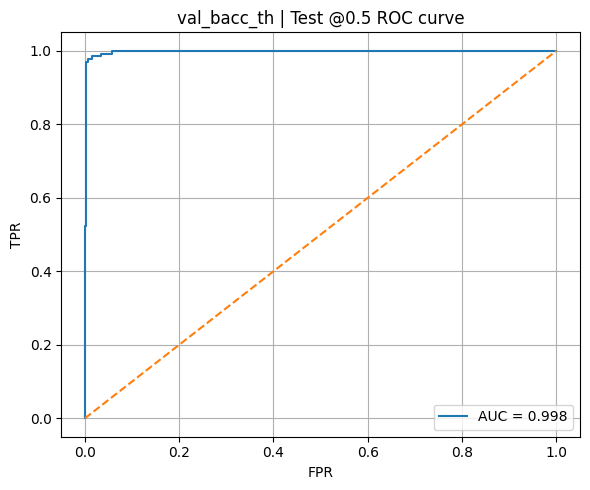

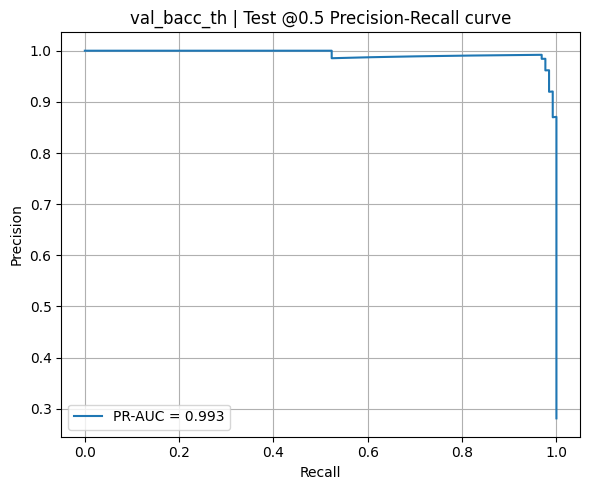

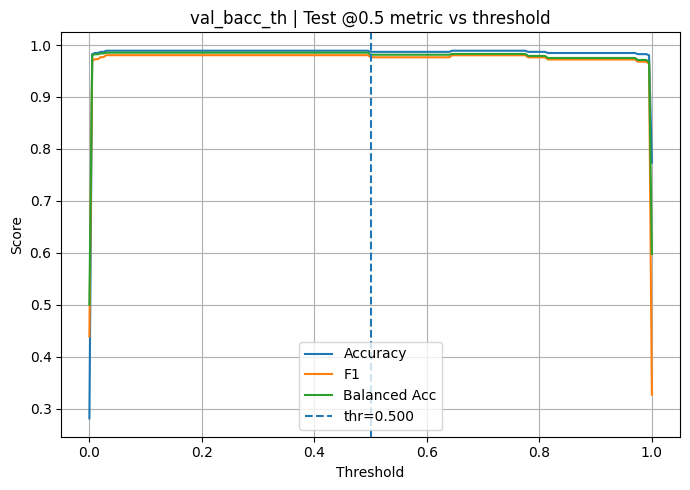

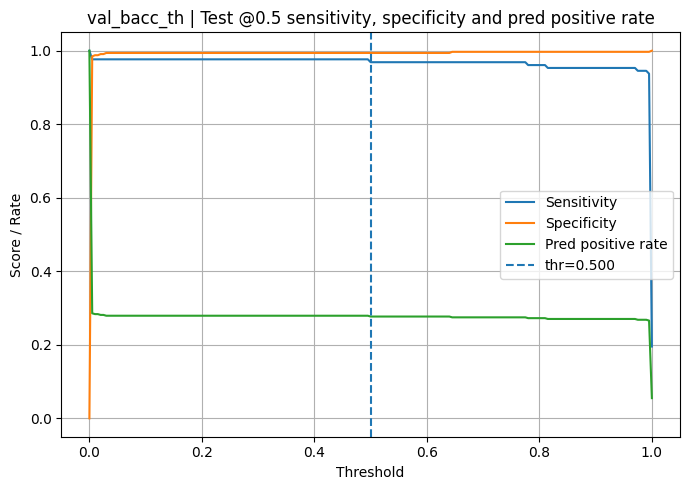

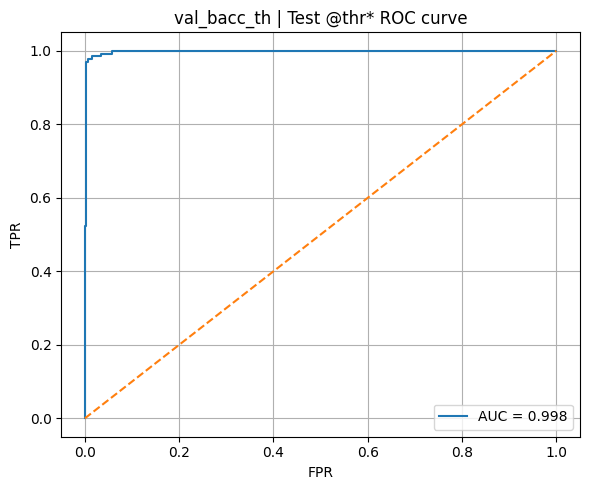

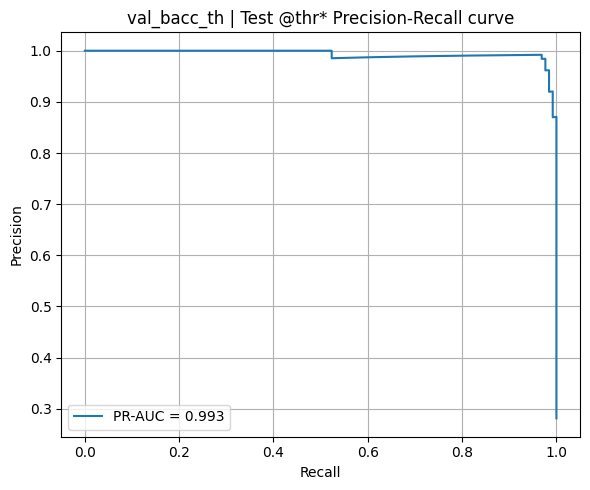

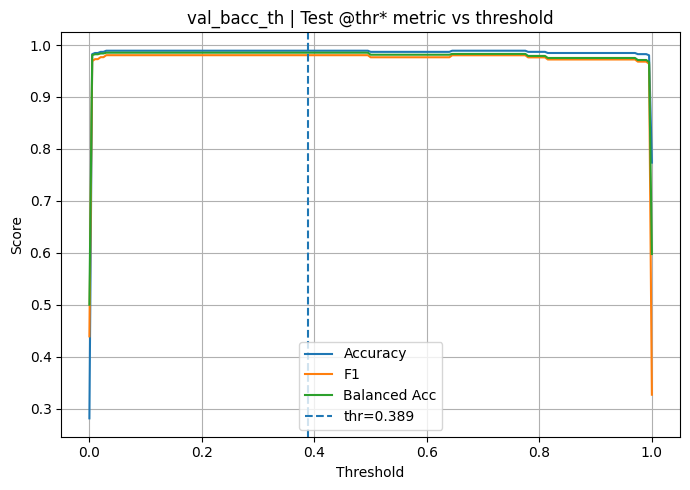

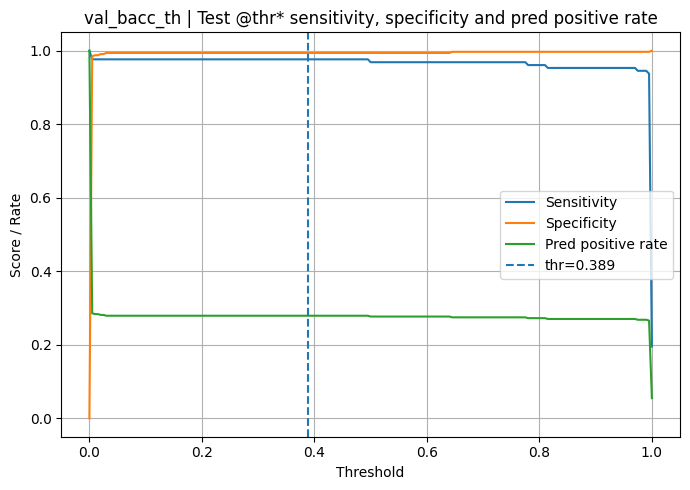

In [24]:
def plot_roc_pr_and_thresholds(res, title_prefix="Test"):
    y_true = res["y_true"]
    probs = res["probs"]

    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {res['auc']:.3f}")
    plt.plot([0,1], [0,1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    prec, rec, _ = precision_recall_curve(y_true, probs)
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label=f"PR-AUC = {res['pr_auc']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision-Recall curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    thrs = np.linspace(0.0, 1.0, 201)
    accs, f1s, baccs = [], [], []
    senss, specs, p1s = [], [], []

    for thr in thrs:
        m = metrics_at_threshold(y_true, probs, thr=thr)
        accs.append(m["acc"])
        f1s.append(m["f1"])
        baccs.append(m["bacc"])
        senss.append(m["sensitivity"])
        specs.append(m["specificity"])
        p1s.append(m["pred_pos_rate"])

    plt.figure(figsize=(7,5))
    plt.plot(thrs, accs, label="Accuracy")
    plt.plot(thrs, f1s, label="F1")
    plt.plot(thrs, baccs, label="Balanced Acc")
    plt.axvline(res["thr"], linestyle="--", label=f"thr={res['thr']:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} metric vs threshold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(thrs, senss, label="Sensitivity")
    plt.plot(thrs, specs, label="Specificity")
    plt.plot(thrs, p1s, label="Pred positive rate")
    plt.axvline(res["thr"], linestyle="--", label=f"thr={res['thr']:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score / Rate")
    plt.title(f"{title_prefix} sensitivity, specificity and pred positive rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_roc_pr_and_thresholds(res05_final,  title_prefix=f"{FINAL_CKPT_NAME} | Test @0.5")
plot_roc_pr_and_thresholds(resthr_final, title_prefix=f"{FINAL_CKPT_NAME} | Test @thr*")

# 22) TABLA RESUMEN DE TODOS LOS CHECKPOINTS

In [25]:
summary_rows = []
for ck_name, pack in test_results_by_ckpt.items():
    r05 = pack["test@0.5"]
    rth = pack["test@thr*"]

    summary_rows.append({
        "checkpoint": ck_name,
        "epoch": pack["epoch"],
        "thr_val": pack["thr_val"],

        "test_acc@0.5": r05["acc"],
        "test_f1@0.5": r05["f1"],
        "test_bacc@0.5": r05["bacc"],
        "test_sens@0.5": r05["sensitivity"],
        "test_spec@0.5": r05["specificity"],
        "test_auc": r05["auc"],
        "test_pr_auc": r05["pr_auc"],

        "test_acc@thr*": rth["acc"],
        "test_f1@thr*": rth["f1"],
        "test_bacc@thr*": rth["bacc"],
        "test_sens@thr*": rth["sensitivity"],
        "test_spec@thr*": rth["specificity"],
    })

summary_df = pd.DataFrame(summary_rows)
print("\nResumen checkpoints en TEST:")
print(summary_df.sort_values(by="test_bacc@thr*", ascending=False).to_string(index=False))


Resumen checkpoints en TEST:
 checkpoint  epoch  thr_val  test_acc@0.5  test_f1@0.5  test_bacc@0.5  test_sens@0.5  test_spec@0.5  test_auc  test_pr_auc  test_acc@thr*  test_f1@thr*  test_bacc@thr*  test_sens@thr*  test_spec@thr*
   val_loss     16 0.870605      0.991209     0.984252       0.986752       0.976562       0.996942  0.998590     0.996485       0.991209      0.984252        0.986752        0.976562        0.996942
val_bacc_th     13 0.388949      0.986813     0.976378       0.981317       0.968750       0.993884  0.997754     0.993220       0.989011      0.980392        0.985223        0.976562        0.993884
  val_f1_th     13 0.388949      0.986813     0.976378       0.981317       0.968750       0.993884  0.997754     0.993220       0.989011      0.980392        0.985223        0.976562        0.993884
    val_auc     13 0.388949      0.986813     0.976378       0.981317       0.968750       0.993884  0.997754     0.993220       0.989011      0.980392        0.985223   

# 23) RESUMEN FINAL

In [26]:
print("\n" + "=" * 70)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("=" * 70)
print(f"Parámetros totales       : {total_p:,}")
print(f"Parámetros cuánticos     : {quantum_p:,}")
print(f"Parámetros clásicos      : {classical_p:,}")

print("\nMejores checkpoints en validación:")
for k, v in best_models.items():
    print(f" - {k}: epoch={v['epoch']} | best={v['best']:.6f} | thr={v['thr']:.3f}")

print(f"\nCheckpoint final usado para curvas: {FINAL_CKPT_NAME}")
print(f"Epoch final: {ep_final}")
print(f"Threshold final: {thr_final:.4f}")

print("\n--- Final Test @0.5 ---")
print(
    f"loss={res05_final['loss']:.4f} | "
    f"acc={res05_final['acc']:.4f} | "
    f"f1={res05_final['f1']:.4f} | "
    f"bAcc={res05_final['bacc']:.4f} | "
    f"sens={res05_final['sensitivity']:.4f} | "
    f"spec={res05_final['specificity']:.4f} | "
    f"AUC={res05_final['auc']:.4f} | "
    f"PR-AUC={res05_final['pr_auc']:.4f}"
)

print("\n--- Final Test @thr* ---")
print(
    f"loss={resthr_final['loss']:.4f} | "
    f"acc={resthr_final['acc']:.4f} | "
    f"f1={resthr_final['f1']:.4f} | "
    f"bAcc={resthr_final['bacc']:.4f} | "
    f"sens={resthr_final['sensitivity']:.4f} | "
    f"spec={resthr_final['specificity']:.4f} | "
    f"AUC={resthr_final['auc']:.4f} | "
    f"PR-AUC={resthr_final['pr_auc']:.4f}"
)

print("\nCM final @0.5:\n", res05_final["cm"])
print("\nCM final @thr*:\n", resthr_final["cm"])


RESUMEN FINAL DEL EXPERIMENTO
Parámetros totales       : 36,189
Parámetros cuánticos     : 0
Parámetros clásicos      : 36,189

Mejores checkpoints en validación:
 - val_loss: epoch=16 | best=0.016827 | thr=0.871
 - val_bacc_th: epoch=13 | best=0.998471 | thr=0.389
 - val_f1_th: epoch=13 | best=0.996109 | thr=0.389
 - val_auc: epoch=13 | best=0.999881 | thr=0.389

Checkpoint final usado para curvas: val_bacc_th
Epoch final: 13
Threshold final: 0.3889

--- Final Test @0.5 ---
loss=0.1564 | acc=0.9868 | f1=0.9764 | bAcc=0.9813 | sens=0.9688 | spec=0.9939 | AUC=0.9978 | PR-AUC=0.9932

--- Final Test @thr* ---
loss=0.1564 | acc=0.9890 | f1=0.9804 | bAcc=0.9852 | sens=0.9766 | spec=0.9939 | AUC=0.9978 | PR-AUC=0.9932

CM final @0.5:
 [[325   2]
 [  4 124]]

CM final @thr*:
 [[325   2]
 [  3 125]]
